In [1]:
import numpy as np
import cupy as cp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures


In [2]:
df = pd.read_csv('/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/f1_strategy_dataset_v4.csv')

df.head()

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101371 entries, 0 to 101370
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  101371 non-null  object 
 1   LapNumber               101371 non-null  int64  
 2   Compound                101305 non-null  object 
 3   Stint                   101371 non-null  int64  
 4   TyreLife                101371 non-null  float64
 5   Position                101371 non-null  int64  
 6   LapTime (s)             101371 non-null  float64
 7   Race                    101371 non-null  object 
 8   Year                    101371 non-null  int64  
 9   LapTime_Delta           101371 non-null  float64
 10  Cumulative_Degradation  101371 non-null  float64
 11  PitStop                 101371 non-null  int64  
 12  PitNextLap              101371 non-null  int64  
 13  RaceProgress            101371 non-null  float64
 14  Normalized_TyreLife 

In [4]:
df.describe()

,LapNumber,Stint,TyreLife,Position,LapTime (s),Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
count,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000
mean,30.444841,2.046394,14.549339,9.759132,92.587188,2023.589685,-0.203891,-29.550051,0.251581,0.254797,0.432618,0.386521,-0.004636
std,18.146942,0.948797,10.313385,5.406456,33.231414,1.098518,45.344910,70.235759,0.433924,0.435749,0.258129,0.259906,3.912725
min,1.000000,1.000000,1.000000,1.000000,67.012000,2022.000000,-2403.895000,-274.564000,0.000000,0.000000,0.012821,0.012821,-18.000000
25%,15.000000,1.000000,7.000000,5.000000,82.021000,2023.000000,-7.253000,-51.054500,0.000000,0.000000,0.210526,0.172414,-2.000000
50%,30.000000,2.000000,13.000000,10.000000,91.167000,2024.000000,-0.027000,-21.678000,0.000000,0.000000,0.421053,0.333333,0.000000
75%,45.000000,3.000000,20.000000,14.000000,99.356000,2025.000000,5.705000,-3.725500,1.000000,1.000000,0.631579,0.562500,2.000000
max,78.000000,8.000000,78.000000,20.000000,2526.253000,2025.000000,2433.472000,2412.431000,1.000000,1.000000,1.000000,1.000000,18.000000


In [5]:
df.dropna(subset=['Compound'], inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101305 entries, 0 to 101370
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  101305 non-null  object 
 1   LapNumber               101305 non-null  int64  
 2   Compound                101305 non-null  object 
 3   Stint                   101305 non-null  int64  
 4   TyreLife                101305 non-null  float64
 5   Position                101305 non-null  int64  
 6   LapTime (s)             101305 non-null  float64
 7   Race                    101305 non-null  object 
 8   Year                    101305 non-null  int64  
 9   LapTime_Delta           101305 non-null  float64
 10  Cumulative_Degradation  101305 non-null  float64
 11  PitStop                 101305 non-null  int64  
 12  PitNextLap              101305 non-null  int64  
 13  RaceProgress            101305 non-null  float64
 14  Normalized_TyreLife     1

In [7]:
mapping = {'SOFT': 0, 'MEDIUM': 1, 'HARD': 2, 'INTERMEDIATE': 3, 'WET': 4}
df['Compound'] = df['Compound'].map(mapping)

df.head(100)

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,1,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,1,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,1,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,1,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,1,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,ALO,38,2,3,3.0,11,88.909,Abu Dhabi Grand Prix,2023,-21.370,-21.370,0,0,0.655172,0.130435,1.0
96,ALO,39,2,3,4.0,11,88.800,Abu Dhabi Grand Prix,2023,-0.109,-21.479,0,0,0.672414,0.173913,0.0
97,ALO,40,2,3,5.0,11,88.617,Abu Dhabi Grand Prix,2023,-0.183,-21.662,0,0,0.689655,0.217391,0.0
98,ALO,41,2,3,6.0,11,88.810,Abu Dhabi Grand Prix,2023,0.193,-21.469,0,0,0.706897,0.260870,0.0


In [8]:
x_num = df.drop(['PitNextLap', 'PitStop'], axis=1).select_dtypes(include='number').values
y = df['PitNextLap'].values

# One-hot encode Driver and Race
drivers = pd.get_dummies(df['Driver'], prefix='D')
races = pd.get_dummies(df['Race'], prefix='R')
x = np.hstack([x_num, drivers.values, races.values])

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Polynomial features (on CPU via sklearn, then move to GPU)
poly = PolynomialFeatures(degree=2, include_bias=False)
x_train = poly.fit_transform(x_train)
x_test  = poly.transform(x_test)

x_train = cp.asarray(x_train)
x_test  = cp.asarray(x_test)
y_train = cp.asarray(y_train).reshape(-1, 1)
y_test  = cp.asarray(y_test).reshape(-1, 1)

# Standardize (fit on train, transform both)
mu    = x_train.mean(axis=0)
sigma = x_train.std(axis=0)
sigma = cp.where(sigma == 0, 1.0, sigma)
x_train = (x_train - mu) / sigma
x_test  = (x_test  - mu) / sigma


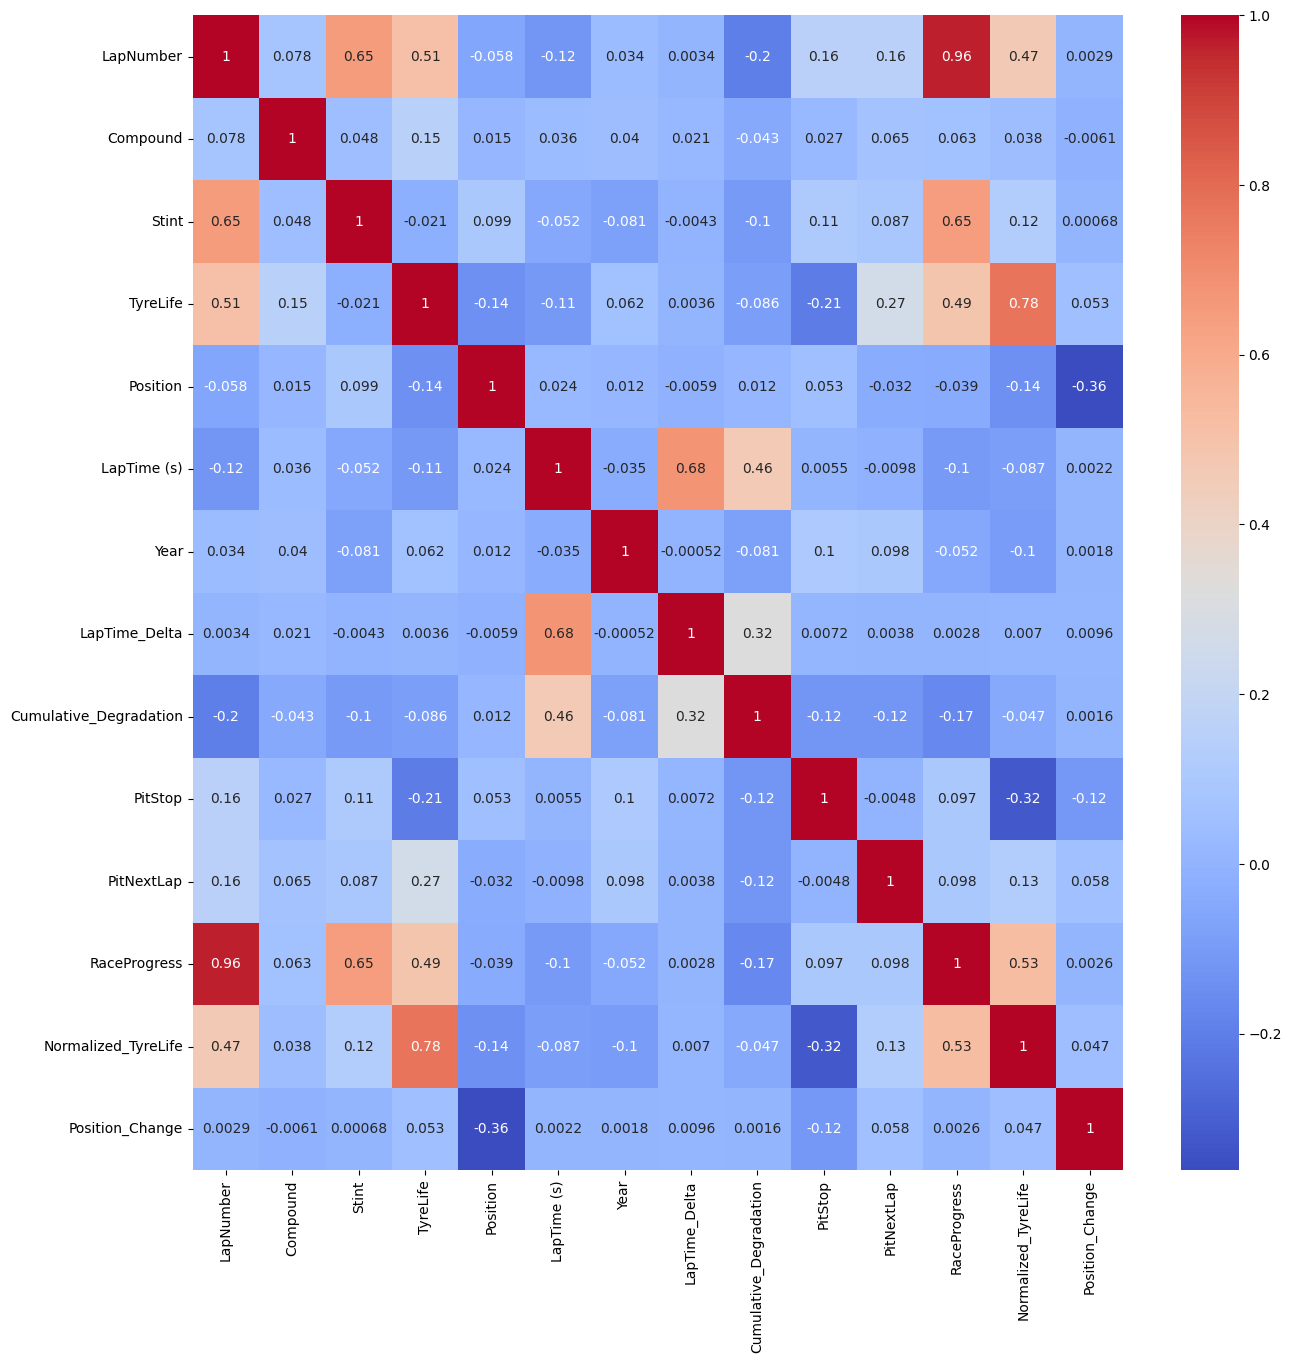

In [9]:
plt.figure(figsize=(15, 15))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap="coolwarm")
plt.show()

In [10]:
# Compute class weights for imbalanced data
n_pos = int(cp.sum(y_train == 1))
n_neg = int(cp.sum(y_train == 0))
w0 = len(y_train) / (2 * n_neg)
w1 = len(y_train) / (2 * n_pos)
sample_weight = cp.where(y_train == 1, w1, w0)
print(f"Class weights — neg: {w0:.3f}, pos: {w1:.3f}")

# Add bias term (ones column)
x_train = cp.hstack([cp.ones((len(x_train), 1)), x_train])
x_test  = cp.hstack([cp.ones((len(x_test),  1)), x_test])


def sigmoid(z):
    return 1 / (1 + cp.exp(-z))


def gradient_descent(x, y, w, alpha, epochs, sample_weight=None, tol=1e-7):
    m = len(y)
    cost_history = []

    if sample_weight is None:
        sample_weight = cp.ones((m, 1))

    for i in range(epochs):
        h = sigmoid(x @ w)
        dj_dw = (1 / m) * (x.T @ (sample_weight * (h - y)))
        w -= alpha * dj_dw

        cost = (-1 / m) * cp.sum(
            sample_weight * (
                y * cp.log(cp.clip(h, 1e-15, 1)) +
                (1 - y) * cp.log(cp.clip(1 - h, 1e-15, 1))
            )
        )
        cost_history.append(cost)

        if i % 1000 == 0:
            print(f"Iter {i}: cost = {float(cost):.6f}")
        if i > 3000 and abs(cost_history[-1] - cost_history[-2]) < tol:
            print(f"Converged at iter {i}")
            break

    return w, cost_history


Class weights — neg: 0.671, pos: 1.958


In [11]:
w = cp.zeros((x_train.shape[1], 1))
w, cost_history = gradient_descent(
    x_train, y_train, w, alpha=0.01, epochs=30000,
)


Iter 0: cost = 0.693147
Iter 1000: cost = 0.392780
Iter 2000: cost = 0.364421
Iter 3000: cost = 0.351947
Iter 4000: cost = 0.344198
Iter 5000: cost = 0.338624
Iter 6000: cost = 0.334284
Iter 7000: cost = 0.330737
Iter 8000: cost = 0.327745
Iter 9000: cost = 0.325163
Iter 10000: cost = 0.322900
Iter 11000: cost = 0.320890
Iter 12000: cost = 0.319089
Iter 13000: cost = 0.317459
Iter 14000: cost = 0.315976
Iter 15000: cost = 0.314619
Iter 16000: cost = 0.313369
Iter 17000: cost = 0.312213
Iter 18000: cost = 0.311140
Iter 19000: cost = 0.310140
Iter 20000: cost = 0.309205
Iter 21000: cost = 0.308328
Iter 22000: cost = 0.307503
Iter 23000: cost = 0.306726
Iter 24000: cost = 0.305991
Iter 25000: cost = 0.305295
Iter 26000: cost = 0.304635
Iter 27000: cost = 0.304007
Iter 28000: cost = 0.303409
Iter 29000: cost = 0.302839


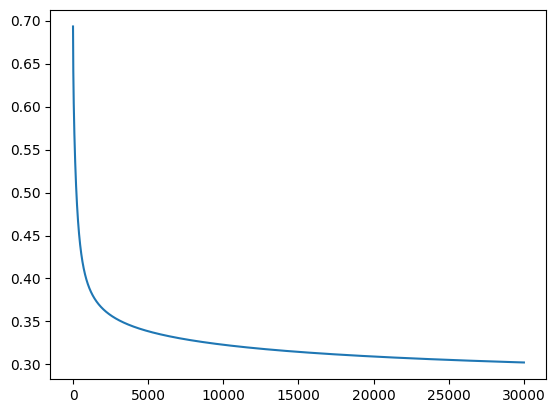

In [12]:
plt.plot(cp.asnumpy(cp.array(cost_history)))

In [13]:
from sklearn.metrics import f1_score
h_test = sigmoid(x_test @ w)

# Sweep thresholds to find the best F1 score
thresholds = cp.linspace(0, 1, 101)
f1_scores = []
for t in thresholds:
    yp = (h_test >= t).astype(int)
    f1_scores.append(f1_score(
        cp.asnumpy(y_test).ravel(),
        cp.asnumpy(yp).ravel()
    ))

best_t = float(thresholds[cp.argmax(cp.array(f1_scores))])
best_f1 = max(f1_scores)
best_acc = float(
    ((h_test >= best_t).astype(int) == y_test).mean()
)
print(f"Best threshold: {best_t:.3f}, F1: {best_f1:.3f}, Acc: {best_acc:.3f}")

y_pred = (h_test >= best_t).astype(int)


Best threshold: 0.390, F1: 0.729, Acc: 0.862


In [14]:
import joblib

feature_cols = list(df.drop(['PitNextLap', 'PitStop'], axis=1)
                  .select_dtypes(include='number').columns)

model = {
    "poly": poly,
    "mu": cp.asnumpy(mu),
    "sigma": cp.asnumpy(sigma),
    "w": cp.asnumpy(w),
    "threshold": best_t,
    "feature_cols": feature_cols,
}
joblib.dump(model, "pit_model.pkl")
print("Saved pit_model.pkl")


Saved pit_model.pkl


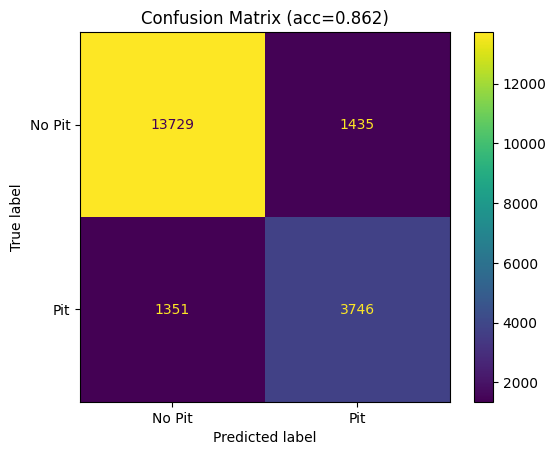

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(cp.asnumpy(y_test), cp.asnumpy(y_pred))
ConfusionMatrixDisplay(cm, display_labels=["No Pit", "Pit"]).plot()
plt.title(f"Confusion Matrix (acc={float(best_acc):.3f})")
plt.show()

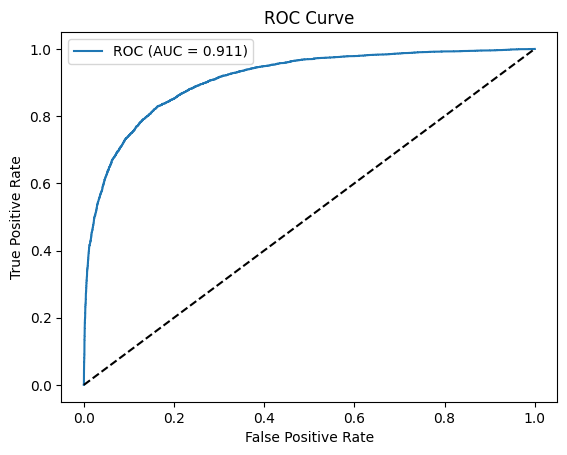

In [16]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(cp.asnumpy(y_test).ravel(), cp.asnumpy(h_test).ravel())
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


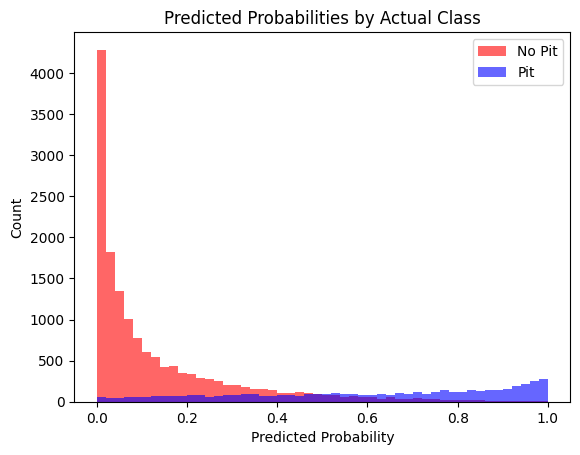

In [17]:
h_pos = cp.asnumpy(h_test[y_test.ravel() == 1]).ravel()
h_neg = cp.asnumpy(h_test[y_test.ravel() == 0]).ravel()
plt.hist(h_neg, bins=50, alpha=0.6, label="No Pit", color="red")
plt.hist(h_pos, bins=50, alpha=0.6, label="Pit", color="blue")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Predicted Probabilities by Actual Class")
plt.legend()
plt.show()


In [18]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

y_true = cp.asnumpy(y_test).ravel()
y_pred_np = cp.asnumpy(y_pred).ravel()

print(classification_report(y_true, y_pred_np, target_names=["No Pit", "Pit"]))
print(f"Precision: {precision_score(y_true, y_pred_np):.3f}")
print(f"Recall:    {recall_score(y_true, y_pred_np):.3f}")
print(f"F1 Score:  {f1_score(y_true, y_pred_np):.3f}")

              precision    recall  f1-score   support

      No Pit       0.91      0.91      0.91     15164
         Pit       0.72      0.73      0.73      5097

    accuracy                           0.86     20261
   macro avg       0.82      0.82      0.82     20261
weighted avg       0.86      0.86      0.86     20261

Precision: 0.723
Recall:    0.735
F1 Score:  0.729
